Today's topics:
* distributions: the *shape* behind a mean and a median
* `np.percentile` and the interquartile range (IQR)
* `plt.hist`: our first plot, one fixed recipe

> By the end of today you should be able to compute percentiles, interpret histograms, and name common distribution shapes

# Comparing distribution shapes

*Can two datasets have the exact same mean and look completely different?*

Two kinds of measurement:
* **Repeated measurement noise**: caliper readings of the same block, scatters symmetrically
* **Grain size**: diameters in a micrograph, can't go below zero, no upper limit → lopsided

# Generating the two datasets

Simulated data, known shape, so we can check our tools recover it.

In [1]:
#@title Setup: import and random seed (click ▶ to run) { display-mode: "form" }
import numpy as np
rng = np.random.default_rng(42)

Seed → reproducible "random" numbers. No seed → different data every run, a debugging headache.

500 caliper readings of a 25 mm block:

In [2]:
#@title Generate: 500 caliper readings (click ▶ to run) { display-mode: "form" }
noise = rng.normal(loc=25.0, scale=0.8, size=500)
print(noise[:10])

[25.24377366 24.16801272 25.60036096 25.75245177 23.43917185 23.95825639
 25.10227232 24.74700593 24.98655907 24.31756486]


`rng.normal` = normal / Gaussian distribution, `loc` = center, `scale` = spread.



<img src="https://upload.wikimedia.org/wikipedia/commons/c/cd/CrystalGrain.jpg" alt="Ti alloy grain microstructure" height=200/>

(Edward Pleshakov, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:CrystalGrain.jpg), [CC BY 3.0](https://creativecommons.org/licenses/by/3.0/))

500 grain diameters (microns), simulated from this kind of microstructure:

In [3]:
#@title Generate: 500 grain diameters (click ▶ to run) { display-mode: "form" }
grain_size = rng.lognormal(mean=np.log(20), sigma=0.5, size=500)
print(grain_size[:10])

[39.553864   31.29082002 13.95715328  9.43551296  4.54245609 15.2409292
 67.08361187 24.85787017 15.11890777 25.23602099]


`np.log` is the natural logarithm (ln). `mean=np.log(20)` is not a typo. lognormal
is defined so the log of the data is normal.

*Why lognormal?* Grain diameters are positive and often right-skewed. Growth
depends on size and boundary curvature, so lognormal is a useful model.
Clustered around 20 microns, some much larger grains possible.

In [4]:
print(f'noise:      mean={np.mean(noise):.3f}, median={np.median(noise):.3f}')
print(f'grain_size: mean={np.mean(grain_size):.3f}, median={np.median(grain_size):.3f}')

noise:      mean=24.989, median=25.003
grain_size: mean=22.195, median=20.088


`noise`: mean ≈ median. `grain_size`: mean noticeably > median, first numeric evidence of asymmetry.

# Percentiles and quartiles

> What value is X% of the data below?

Median = 50th percentile. 25th (Q1) and 75th (Q3) bound the middle half.

In [5]:
levels = np.array([25, 50, 75])
quartiles = np.percentile(noise, levels)
q1 = quartiles[0]
q2 = quartiles[1]
q3 = quartiles[2]
print(f'noise: Q1={q1:.3f}, median={q2:.3f}, Q3={q3:.3f}')

noise: Q1=24.466, median=25.003, Q3=25.470


`q2 - q1` ≈ `q3 - q2`: symmetric.

In [6]:
levels = np.array([25, 50, 75])
quartiles = np.percentile(grain_size, levels)
q1 = quartiles[0]
q2 = quartiles[1]
q3 = quartiles[2]
print(f'grain_size: Q1={q1:.3f}, median={q2:.3f}, Q3={q3:.3f}')

grain_size: Q1=13.918, median=20.088, Q3=26.943


`q3 - q2` >> `q2 - q1`: lopsided. Long right tail, same phenomenon as the mean/median gap above.

## Interquartile range (IQR)

$$\text{IQR} = Q_3 - Q_1$$

(reusing `q1`, `q3` from `grain_size` above)

In [7]:
iqr = q3 - q1
print(f'IQR = {iqr:.3f}')

IQR = 13.026


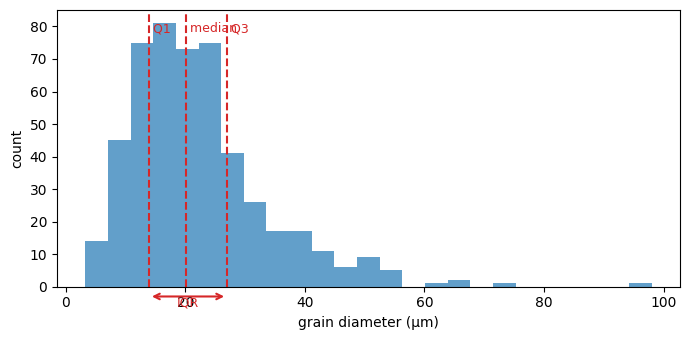

In [8]:
#@title Visualization: quartiles and IQR on grain-size data (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(grain_size, bins=25, alpha=0.7, color='C0')
for val, label in [(q1, 'Q1'), (q2, 'median'), (q3, 'Q3')]:
    ax.axvline(val, color='C3', linestyle='--')
    ax.text(val, ax.get_ylim()[1] * 0.92, f' {label}', fontsize=9, color='C3')
ax.annotate('', xy=(q3, -3), xytext=(q1, -3),
            arrowprops=dict(arrowstyle='<->', color='C3', lw=1.5),
            annotation_clip=False)
ax.text((q1 + q3) / 2, -6, 'IQR', ha='center', fontsize=9, color='C3',
        clip_on=False)
ax.set_xlabel('grain diameter (μm)')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

IQR sees the middle 50%, so extremes barely move it. Std uses every point's
squared deviation, so one large value inflates it.

*Which percentile matters?* Depends on the question:
* Process consistency: IQR (middle 50%)
* Fracture-critical microstructure: upper tail ("no more than 5% above X microns")

That cutoff is the 95th percentile:

In [9]:
p95 = np.percentile(grain_size, 95)
print(f'95th percentile grain diameter: {p95:.1f} microns')

95th percentile grain diameter: 44.9 microns


### [Check your understanding]

Using `grain_size`:
* Compute the 10th and 90th percentiles using `levels = np.array([10, 90])` and `np.percentile(grain_size, levels)`
* Compute the "80% spread" between them
* Compare to IQR above: which is bigger, and does that make sense?

## Hands-on: certifying a ceramic

Alumina (Al₂O₃) is a brittle ceramic. Its fracture strength is measured by
loading many identical bars to failure and recording the stress at fracture.
Because brittle fracture initiates at the largest flaw in each bar, strength
distributions for ceramics are often left-skewed: most bars cluster near a
typical strength, but a few weak bars, with larger flaws, pull the low tail down.

60 fracture strengths (synthetic teaching data, calibrated from published Weibull parameters) (MPa), two batches of 30 bars each, run below.

In [10]:
#@title Alumina fracture strength data (click ▶ to run) { display-mode: "form" }
strength = np.array([334.67, 363.23, 366.2, 331.22, 326.89, 266.17, 298.75, 343.56,
                      340.32, 317.58, 250.32, 335.88, 385.47, 290.1, 321.96, 299.65,
                      264.61, 226.66, 344.5, 381.01, 340.62, 328.68, 286.74, 326.17,
                      359.21, 340.67, 239.63, 348.9, 290.83, 349.59,
                      298.47, 307.75, 294.88, 297.75, 304.99, 332.21, 314.05, 328.36,
                      291.86, 272.36, 348.09, 354.77, 310.55, 369.92, 229.08, 300.36,
                      291.1, 320.99, 258.6, 244.93, 232.71, 246.3, 313.14, 233.25,
                      321.66, 317.52, 289.2, 288.62, 288.81, 350.41])
print(len(strength))

60


The first 30 values are batch A, the last 30 are batch B.

Compute the mean and median of `strength`. Which is larger? Does that match a
left skew (long low tail) or a right skew (long high tail)?

A design allowable is often set well below the average, to cover the weak tail.
Compute the 10th percentile of `strength` with `np.percentile`. That is the value
below which only 10% of bars fractured, a common conservative design value for
brittle materials.

Use slicing to split `strength` into `batch_A` (the first 30 values) and
`batch_B` (the last 30 values). Compute the mean and standard deviation of each.
Are the two batches close enough to call them the same process, or does one look
weaker or more variable than the other?

# Histograms for reading distribution shape

The plotting code below is for visualization only.
Focus on the shape of each histogram, not the code that draws it.

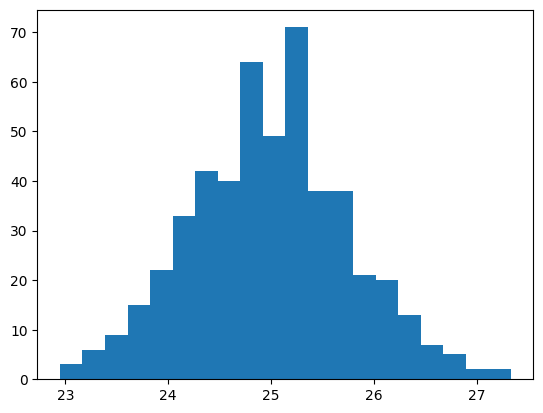

In [11]:
#@title Visualization: histogram of noise data (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt
plt.hist(noise, bins=20)
plt.show()

Symmetric bell shape, peak near 25.0, a **normal distribution**. Same recipe, swap the array:

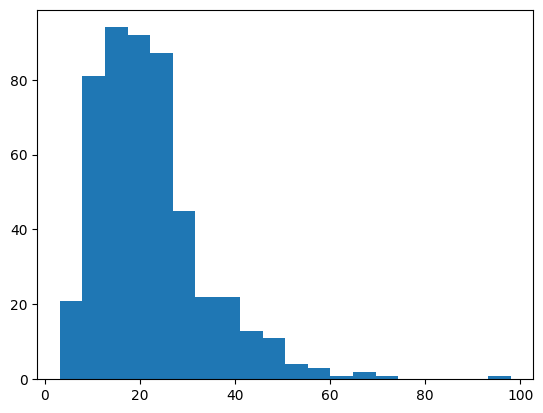

In [12]:
#@title Visualization: histogram of grain_size data (click ▶ to run) { display-mode: "form" }
plt.hist(grain_size, bins=20)
plt.show()

Cluster on the small side, long tail right, a **right skew**. Visual confirmation of the lopsided quartiles and mean > median above.

`bins` is a resolution setting, not a fact about the data.

> **Read more:** [PDSH -- Histograms and Binnings](https://jakevdp.github.io/PythonDataScienceHandbook/04.05-histograms-and-binnings.html)

### [Check your understanding]

* Plot `noise` with `bins=10` instead of `bins=20`: still symmetric?
* Compute `np.mean(noise) - np.median(noise)` and `np.mean(grain_size) - np.median(grain_size)`: which is closer to zero, matching which skew?

# Naming the shapes

* **Symmetric**: equal tails, mean ≈ median. `noise`.
* **Right-skewed**: long tail high, mean > median. `grain_size`, a **lognormal**.

*Why these shapes?* Additive errors average symmetrically (normal). Growth that
depends on current size produces positive, right-skewed data (approximately lognormal).

Lognormal: pore sizes, powder particles, defect clusters. Normal: measurement error, thermal noise.




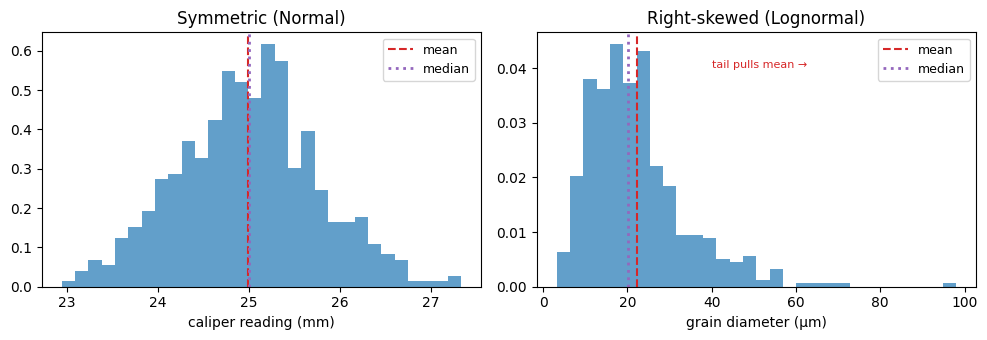

In [13]:
#@title Visualization: symmetric vs right-skewed with mean and median (click ▶ to run) { display-mode: "form" }
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.hist(noise, bins=30, density=True, alpha=0.7, color='C0')
ax1.axvline(np.mean(noise), color='C3', linestyle='--', label='mean')
ax1.axvline(np.median(noise), color='C4', linestyle=':', linewidth=2, label='median')
ax1.set_title('Symmetric (Normal)')
ax1.set_xlabel('caliper reading (mm)')
ax1.legend(fontsize=9)

ax2.hist(grain_size, bins=30, density=True, alpha=0.7, color='C0')
ax2.axvline(np.mean(grain_size), color='C3', linestyle='--', label='mean')
ax2.axvline(np.median(grain_size), color='C4', linestyle=':', linewidth=2, label='median')
ax2.annotate('tail pulls mean →', xy=(np.mean(grain_size), 0),
             xytext=(40, 0.04), fontsize=8, color='C3')
ax2.set_title('Right-skewed (Lognormal)')
ax2.set_xlabel('grain diameter (μm)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
#
# Symmetric → mean, median, mode coincide. Skewed → they pull apart, mean moves furthest toward the tail.

# Quiz 1

Close laptops. Closed-notes, paper, ~15 min.

Fair game: array creation, shape, 1D/2D indexing, arithmetic/broadcasting,
mean/median/variance/standard deviation, percentiles, reading a histogram,
`axis=0` vs. `axis=1`, and scalar/vector/matrix plus
integer/float/categorical vocabulary.


## Further reading

- [VanderPlas: Aggregations (min, max, and everything in between)](https://jakevdp.github.io/PythonDataScienceHandbook/02.04-computation-on-arrays-aggregates.html)
- [VanderPlas: Histograms and binnings](https://jakevdp.github.io/PythonDataScienceHandbook/04.05-histograms-and-binnings.html)